# Cultura Database — Getting Started

This notebook shows how to load and query the Cultura Database using DuckDB and Polars.

**Example**: Pick a polity and count the individuals active in it (using the floruit period), then plot how that count evolves over time.

In [1]:
import duckdb
import polars as pl
import matplotlib.pyplot as plt

## 1. Connect to the Database

The database is located at `data/humans_clean.duckdb`. We open it in read-only mode and pull results straight into Polars via DuckDB's native `.pl()` method.

In [2]:
DB_PATH = "data/humans_clean.duckdb"
con = duckdb.connect(DB_PATH, read_only=True)

# Quick check: how many individuals in the database?
total = con.execute("SELECT COUNT(*) AS n FROM individuals").pl()
print(f"Total individuals: {total['n'][0]:,}")

Total individuals: 13,003,420


## 2. Count Active Individuals in a Polity

The table `individuals_cliopatria` links each individual to one or more polities based on the **floruit period** (years of activit). Counting rows per polity therefore yields the number of individuals *active* in that polity.

We illustrate this on the **Tang Dynasty**.

In [3]:
polities = ["Tang Dynasty"]

active_counts = con.execute("""
    SELECT polity_name, COUNT(*) AS active_individuals
    FROM individuals_cliopatria
    WHERE polity_name IN ?
    GROUP BY polity_name
    ORDER BY active_individuals DESC
""", [polities]).pl()

print("Active individuals per polity:")
active_counts

Active individuals per polity:


polity_name,active_individuals
str,i64
"""Tang Dynasty""",25675


In [4]:
# Pull each individual's floruit PERIOD (start/end) for the three polities.
# An individual has impact across its whole floruit period, not just one year.
df = con.execute("""
    SELECT polity_name, wikidata_id, name_en,
           floruit_period_start, floruit_period_end
    FROM individuals_cliopatria
    WHERE polity_name IN ?
      AND floruit_period_start IS NOT NULL
      AND floruit_period_end   IS NOT NULL
""", [polities]).pl()

print(f"Rows: {len(df):,}")
df.head(10)

Rows: 25,675


polity_name,wikidata_id,name_en,floruit_period_start,floruit_period_end
str,str,str,i32,i32
"""Tang Dynasty""","""Q1001807""","""Khúc Thừa Dụ""",801,900
"""Tang Dynasty""","""Q1005372""","""Qilibi Khan""",617,645
"""Tang Dynasty""","""Q10056776""","""Qibi Heli""",646,672
"""Tang Dynasty""","""Q1008025""","""Nanquan Puyuan""",777,803
"""Tang Dynasty""","""Q10975505""","""Li Yuanying""",653,679
"""Tang Dynasty""","""Q10987941""","""Li Zaiyi""",822,837
"""Tang Dynasty""","""Q11002835""","""Zhu Fang""",755,781
"""Tang Dynasty""","""Q11021468""","""Wukong""",765,798
"""Tang Dynasty""","""Q11660158""","""""",727,753


## 3. Plot Active Individuals by 50-Year Bin

For each polity, we group active individuals by 50-year bin. Each individual is counted in every bin its **floruit period** spans.

Tang Dynasty official span: 623–910


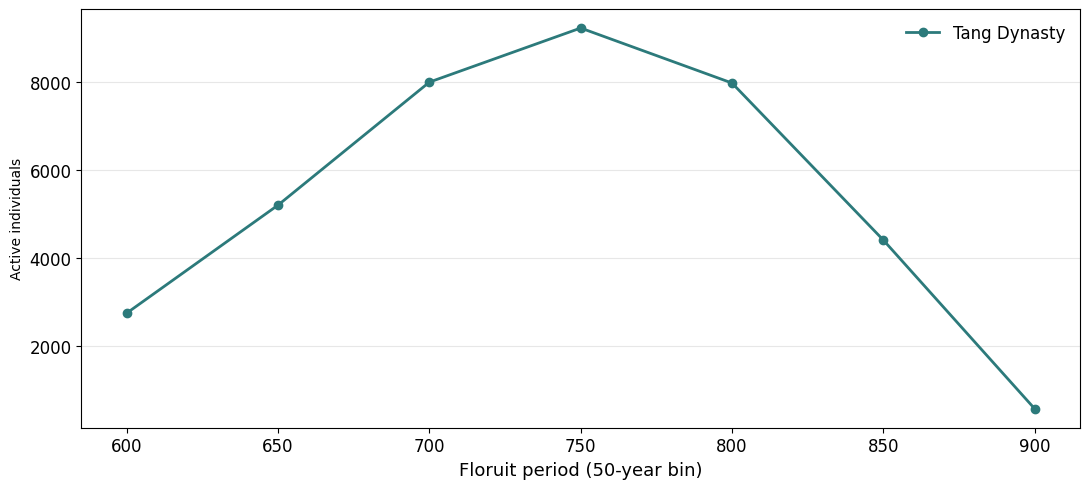

In [5]:
POLITY_TO_PLOT = "Tang Dynasty"

# Official lifespan of the polity, as defined in Cliopatria.
span = con.execute("""
    SELECT MIN(from_year) AS start, MAX(to_year) AS end
    FROM polities_periods_cliopatria
    WHERE polity_name = ?
""", [POLITY_TO_PLOT]).pl()
p_start, p_end = span["start"][0], span["end"][0]
print(f"{POLITY_TO_PLOT} official span: {p_start}–{p_end}")

# Count each individual in every 50-year bin its floruit period covers,
# then keep only the bins that fall within the polity's official lifespan.
by_bin = (
    df
    .filter(pl.col("polity_name") == POLITY_TO_PLOT)
    .with_columns(
        start_bin=(pl.col("floruit_period_start") // 50) * 50,
        end_bin=(pl.col("floruit_period_end") // 50) * 50,
    )
    .with_columns(bin=pl.int_ranges("start_bin", pl.col("end_bin") + 50, 50))
    .explode("bin")
    .group_by("bin")
    .agg(pl.len().alias("count"))
    .filter(pl.col("count") > 0)  # skip bins with no active individuals
    .filter((pl.col("bin") <= p_end) & (pl.col("bin") + 50 > p_start))  # clip to official span
    .sort("bin")
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(by_bin["bin"].to_list(), by_bin["count"].to_list(),
        marker="o", linewidth=2, color="#2c7a7b", label=POLITY_TO_PLOT)

ax.set_xlabel("Floruit period (50-year bin)", fontsize=13)
ax.set_ylabel("Active individuals")
ax.legend(fontsize=12, frameon=False)
ax.grid(axis="y", alpha=0.3)
ax.tick_params(labelsize=12)
plt.tight_layout()
plt.show()

## 4. Explore Historical Polities

Query individuals linked to historical polities via Cliopatria.

In [6]:
# Top 10 polities by number of individuals
top_polities = con.execute("""
    SELECT polity_name, COUNT(*) AS n
    FROM individuals_cliopatria
    GROUP BY polity_name
    ORDER BY n DESC
    LIMIT 10
""").pl()
print("Top 10 historical polities:")
top_polities

Top 10 historical polities:


polity_name,n
str,i64
"""United States of America""",707036
"""Union of Soviet Socialist Repu…",409620
"""British Empire""",330276
"""Kingdom of Great Britain""",309693
"""Nazi Germany""",306649
"""French Fifth Republic""",250250
"""Federated Republic of Germany""",193900
"""Japan""",172229
"""Kingdom of Spain""",148105


In [7]:
# Writers in the Tang Dynasty
tang_writers = con.execute("""
    SELECT ic.name_en, ic.floruit_year, ic.polity_name
    FROM individuals_cliopatria ic
    JOIN individuals i ON ic.wikidata_id = i.wikidata_id
    WHERE ic.polity_name = 'Tang Dynasty'
      AND i.occupations_en LIKE '%writer%'
    ORDER BY ic.floruit_year
    LIMIT 20
""").pl()
print("Writers in the Tang Dynasty:")
tang_writers

Writers in the Tang Dynasty:


name_en,floruit_year,polity_name
str,i32,str
"""Empress Shen Wuhua""",600,"""Tang Dynasty"""
"""Tao-cho""",612,"""Tang Dynasty"""
"""Xiao Gai""",614,"""Tang Dynasty"""
"""Li Baiyao""",616,"""Tang Dynasty"""
"""Kong Yingda""",621,"""Tang Dynasty"""
…,…,…
"""Wang Bo""",676,"""Tang Dynasty"""
"""Du Sixian""",676,"""Tang Dynasty"""
"""Huaigan""",681,"""Tang Dynasty"""


## 5. Extract Individuals by Occupation, Polity & Floruit Period

Pull every individual of a given **occupation**, active within a given **polity**, together with their **floruit period**. Change `OCCUPATION` and `POLITY` to query anything.

`individuals_cliopatria` is multi-polity (one row per individual–polity pair), so this returns each matching person once for the chosen polity, with the floruit window that overlapped it.

In [8]:
OCCUPATION = "writer"          # matched as a substring of occupations_en
POLITY     = "Tang Dynasty"    # exact polity name from polities_cliopatria

people = con.execute("""
    SELECT
        ic.name_en,
        i.occupations_en,
        fp.floruit_period,
        ic.polity_name
    FROM individuals_cliopatria ic
    JOIN individuals i ON ic.wikidata_id = i.wikidata_id
    LEFT JOIN individuals_floruit_period fp ON ic.wikidata_id = fp.wikidata_id
    WHERE ic.polity_name = ?
      AND i.occupations_en LIKE '%' || ? || '%'
    ORDER BY fp.floruit_period_start
""", [POLITY, OCCUPATION]).pl()

print(f"{OCCUPATION}s active in the {POLITY}: {len(people):,}")
people.head(20)

writers active in the Tang Dynasty: 217


name_en,occupations_en,floruit_period,polity_name
str,str,str,str
"""Empress Shen Wuhua""","""writer; poet""","""6th-7th c. AD""","""Tang Dynasty"""
"""Tao-cho""","""writer; Buddhist monk""","""596-629""","""Tang Dynasty"""
"""Li Baiyao""","""historian; writer; poet; polit…","""597-636""","""Tang Dynasty"""
"""Xiao Gai""","""scholar; writer; politician""","""601-627""","""Tang Dynasty"""
"""Wang Xuance""","""diplomat; historian; writer""","""7th c. AD""","""Tang Dynasty"""
…,…,…,…
"""Lu Zhaolin""","""writer; poet""","""664-686""","""Tang Dynasty"""
"""Huaigan""","""writer; Buddhist monk""","""668-694""","""Tang Dynasty"""
"""Li Jiao""","""writer; poet""","""669-695""","""Tang Dynasty"""


In [9]:
con.close()